In [1]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading, Understanding the data**

In [2]:
# load the dataset
df = pd.read_csv("/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
print("Dataset dimensions:", df.shape)

Dataset dimensions: (45000, 14)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
print("Number of missing values:")
df.isnull().sum()

Number of missing values:


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# seperate numerical and categorical columns
df_cat = df.select_dtypes(['object'])
df_num = df.select_dtypes(['int64', 'float64'])

In [8]:
df_cat.describe()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,45000,45000,45000,45000,45000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,24841,13399,23443,9153,22858


In [9]:
# get unique categories for each categorical feature
print("Unique categories:")
for col in df_cat.columns:
    print(f"{col} -> {df[col].unique()}")

Unique categories:
person_gender -> ['female' 'male']
person_education -> ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership -> ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent -> ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file -> ['No' 'Yes']


In [10]:
df_num.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
10%,22.000000,3.511890e+04,0.000000,3000.000000,6.990000,0.040000,2.000000,563.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
90%,35.000000,1.332761e+05,13.000000,19200.000000,14.970000,0.260000,11.000000,692.000000,1.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


#### Note:
- loan_status = 0 => loan approved
- loan_status = 1 => loan rejected

## **Data Preprocessing**

- #### SMOTE generated synthetic data is being used, so there are NO MISSING VALUES

#### **Clean Data**

In [11]:
# convert datatypes
df['person_age'] = df['person_age'].astype(np.int64)
df['loan_status'] = df['loan_status'].astype(object)

In [12]:
# rename required columns
df.rename(columns={
    'loan_amnt': 'loan_amount',
    'loan_int_rate': 'loan_interest_rate',
    'cb_person_cred_hist_length': 'credit_hist_length',
    'previous_loan_defaults_on_file': 'prev_loan_defaults'
}, inplace=True)

In [13]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_interest_rate,loan_percent_income,credit_hist_length,credit_score,prev_loan_defaults,loan_status
0,22,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


#### **Handling Outliers**

In [14]:
# select numerical features
num_cols = df.select_dtypes(['int64', 'float64']).columns

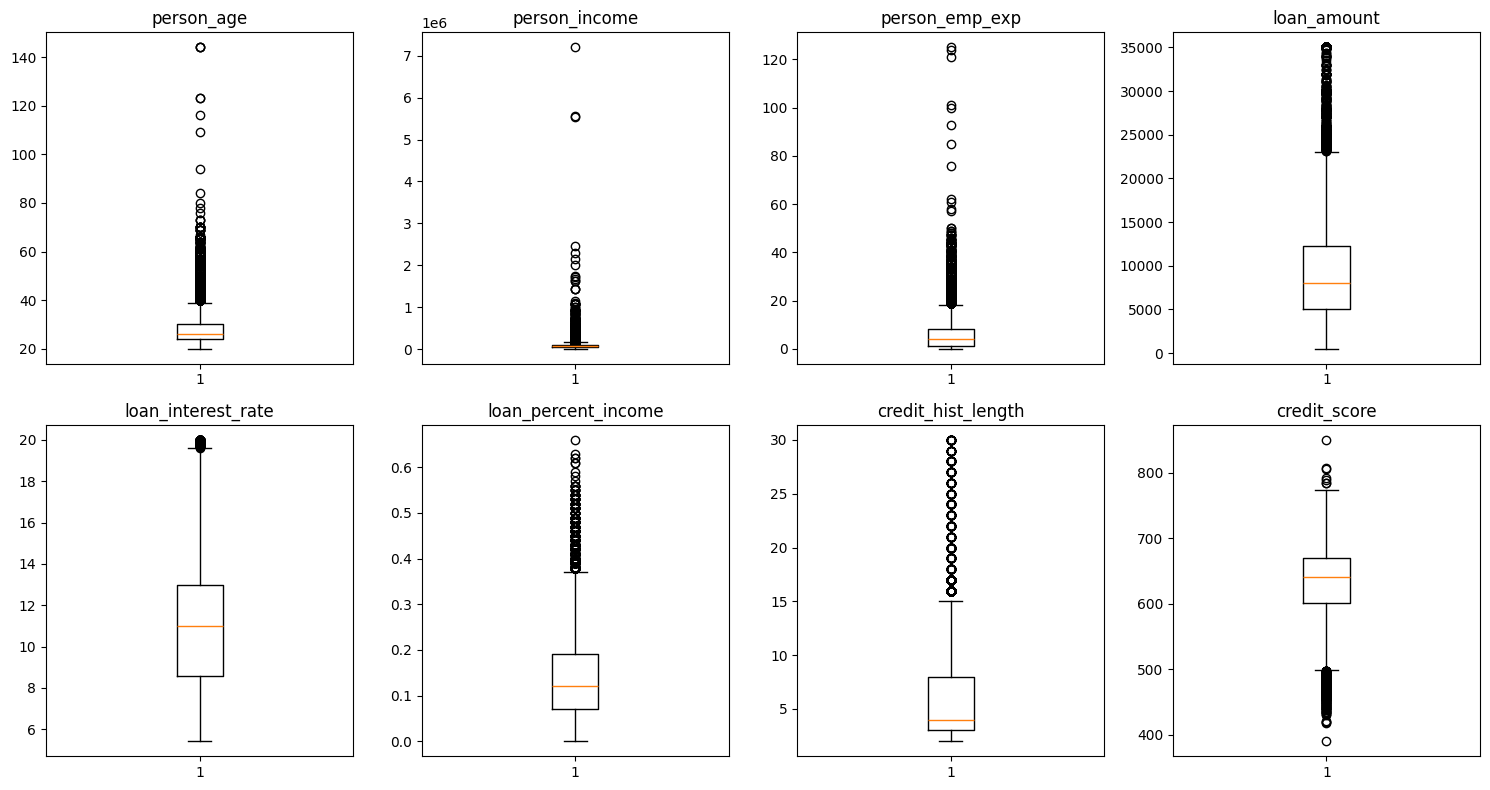

In [15]:
# check for outliers using boxplot
fig, ax = plt.subplots(2, 4, figsize=(15, 8))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(2, 4, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
# remove outliers using trimming
df = df[(df['person_age'] <= 100) & (df['person_emp_exp'] <= 60)]

In [17]:
# remove outliers using percentile
for col in num_cols.drop(['person_age', 'person_emp_exp', 'loan_percent_income', 'credit_score']):
    upper_limit = df[col].quantile(0.999)
    df = df[df[col] < upper_limit]

In [18]:
df.shape

(44567, 14)

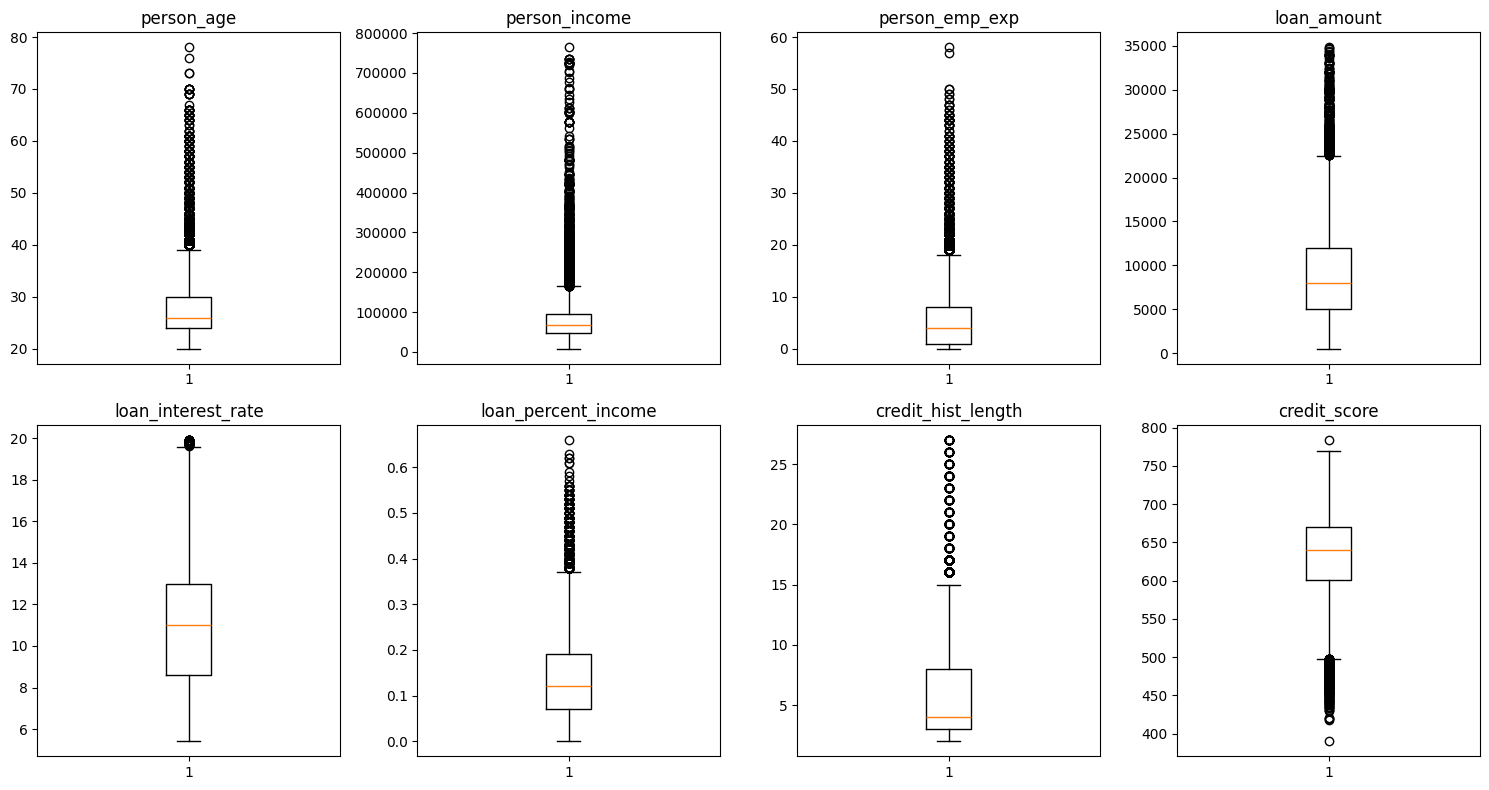

In [19]:
# recheck outliers
fig, ax = plt.subplots(2, 4, figsize=(15, 8))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(2, 4, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis**

#### **Statistical Analysis**

In [20]:
# split categorical and numerical features
df_cat = df.select_dtypes(['object'])
df_num = df.select_dtypes(['int64', 'float64'])

In [21]:
df_cat.describe()

,person_gender,person_education,person_home_ownership,loan_intent,prev_loan_defaults,loan_status
count,44567,44567,44567,44567,44567,44567
unique,2,5,4,6,2,2
top,male,Bachelor,RENT,EDUCATION,Yes,0
freq,24591,13284,23288,9081,22693,34730


In [22]:
df_num.describe()

,person_age,person_income,person_emp_exp,loan_amount,loan_interest_rate,loan_percent_income,credit_hist_length,credit_score
count,44567.000000,44567.00000,44567.000000,44567.000000,44567.000000,44567.000000,44567.000000,44567.000000
mean,27.682613,78274.52577,5.330917,9439.261696,10.981793,0.139261,5.817735,632.511477
std,5.770082,50460.93549,5.787524,6045.555190,2.952204,0.086739,3.761307,50.378873
min,20.000000,8000.00000,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000
25%,24.000000,47041.00000,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000
50%,26.000000,66952.00000,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000
75%,30.000000,94734.50000,8.000000,12000.000000,12.990000,0.190000,8.000000,670.000000
max,78.000000,764203.00000,58.000000,34826.000000,19.910000,0.660000,27.000000,784.000000


#### **Univariate Analysis**

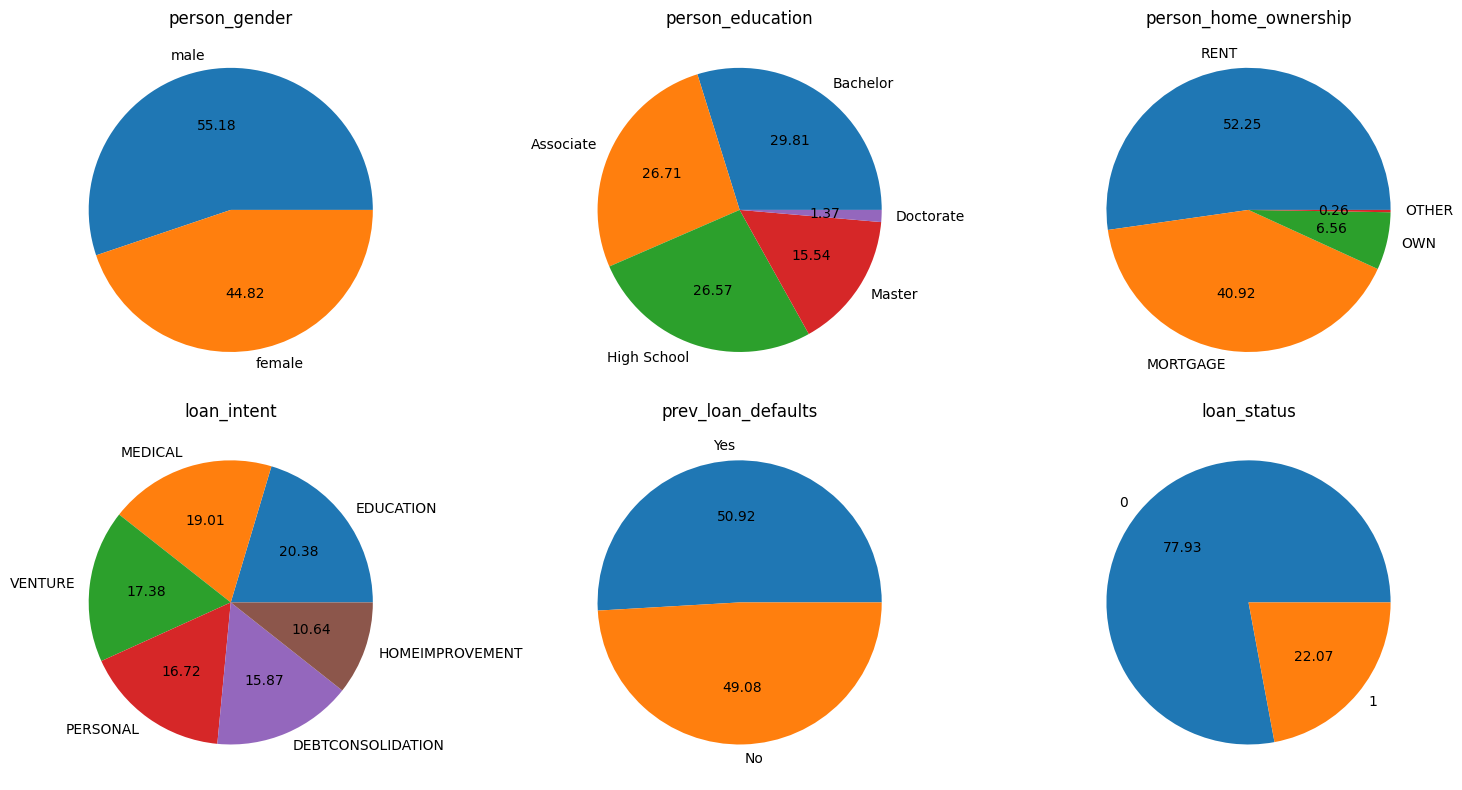

In [23]:
# analyze categorical features
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(df_cat.columns, start=1):
    plt.subplot(2, 3, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%.2f')
    plt.title(col)

plt.tight_layout()
plt.show()

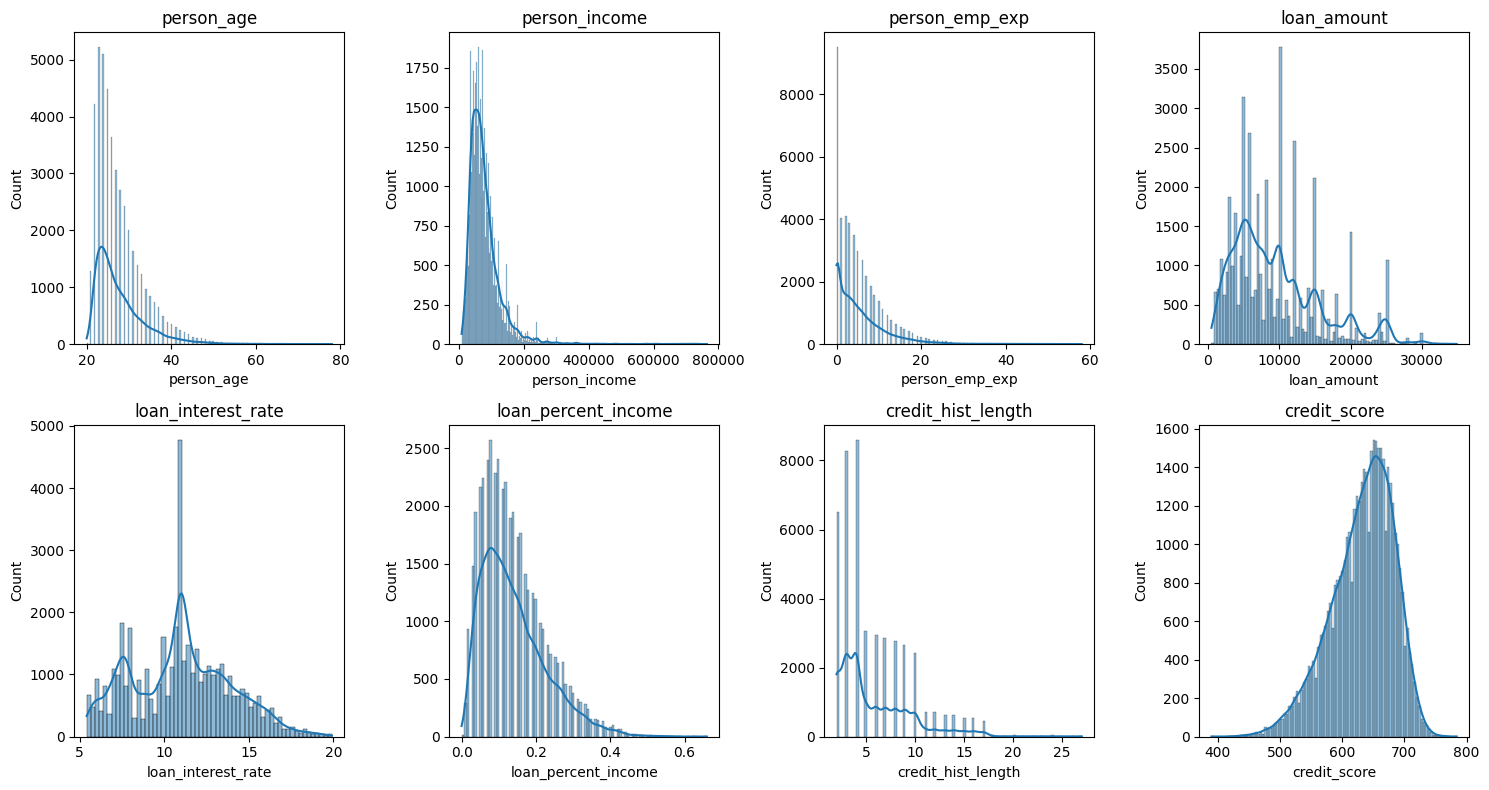

In [24]:
# analyze numerical features
fig, ax = plt.subplots(2, 4, figsize=(15, 8))

for i, col in enumerate(df_num.columns, start=1):
    plt.subplot(2, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

#### **Correlation Analysis**

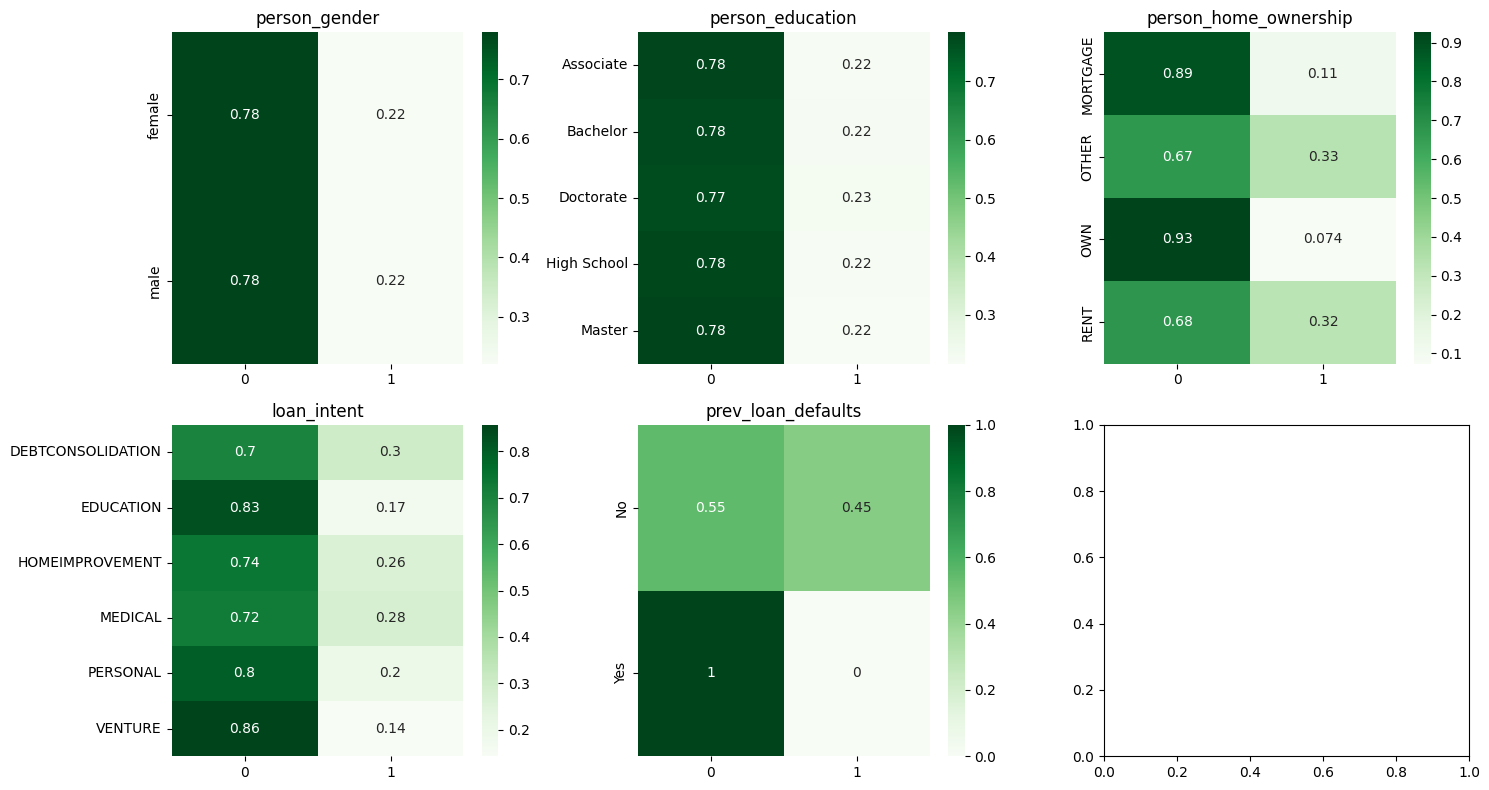

In [25]:
# for categorical features (use heatmap)
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(df_cat.drop('loan_status', axis=1).columns, start=1):
    pivot_table = pd.crosstab(df[col], df['loan_status'])
    pct_pivot_table = pivot_table.copy()
    pct_pivot_table[0] = pivot_table[0] / pivot_table.sum(axis=1)
    pct_pivot_table[1] = pivot_table[1] / pivot_table.sum(axis=1)

    plt.subplot(2, 3, i)
    sns.heatmap(pct_pivot_table, annot=True, cmap='Greens')
    plt.xlabel('')
    plt.ylabel('')
    plt.title(col)

plt.tight_layout()
plt.show()

##### Note: in the dataset, prev_loan_defaults values are inverted
##### ie. 'Yes' <--> 'No'

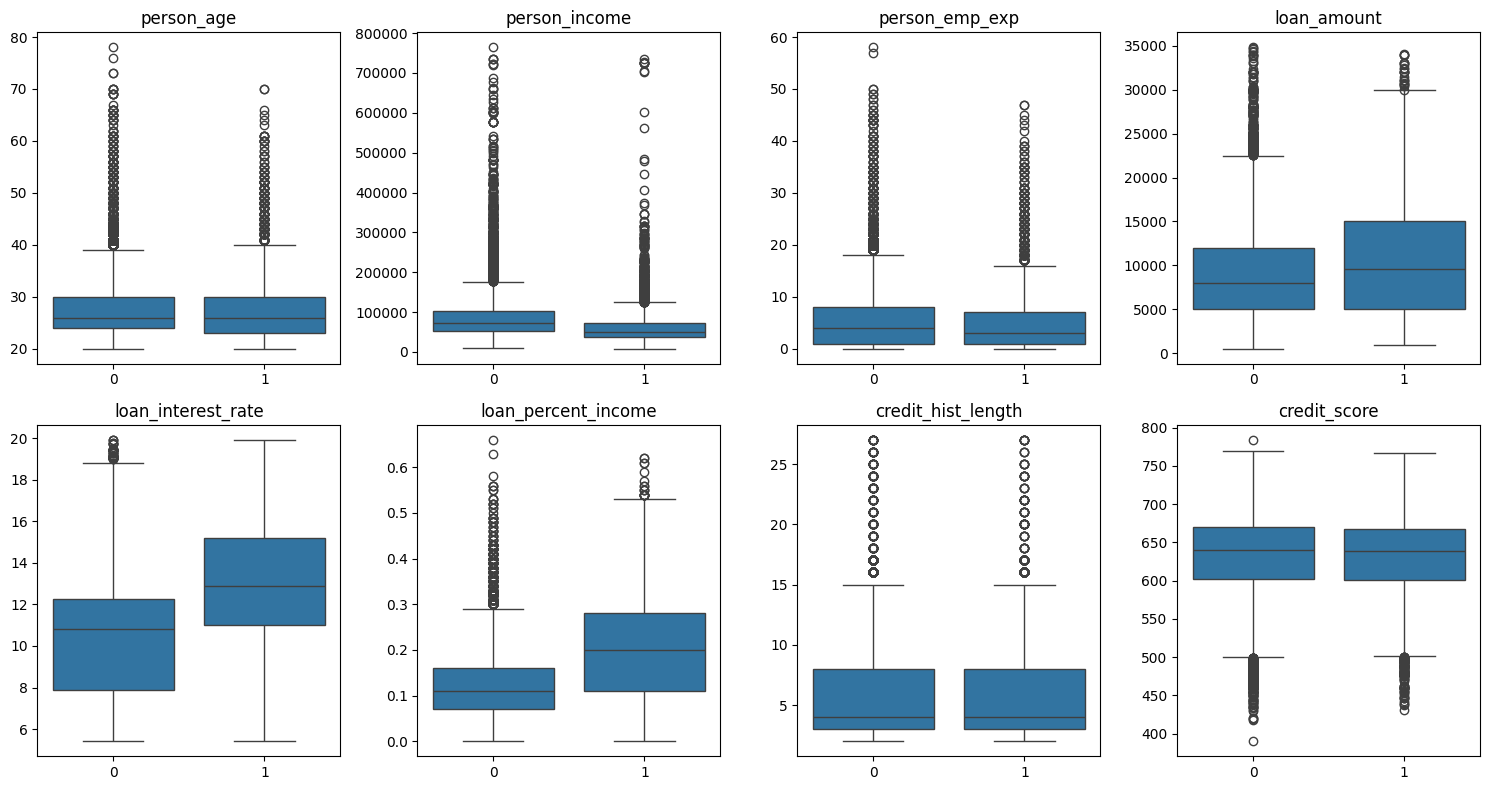

In [26]:
# for numerical features (using boxplots)
fig, ax = plt.subplots(2, 4, figsize=(15, 8))

for i, col in enumerate(df_num.columns, start=1):
    plt.subplot(2, 4, i)
    sns.boxplot(data=df, x='loan_status', y=col)
    plt.xlabel('')
    plt.ylabel('')
    plt.title(col)

plt.tight_layout()
plt.show()

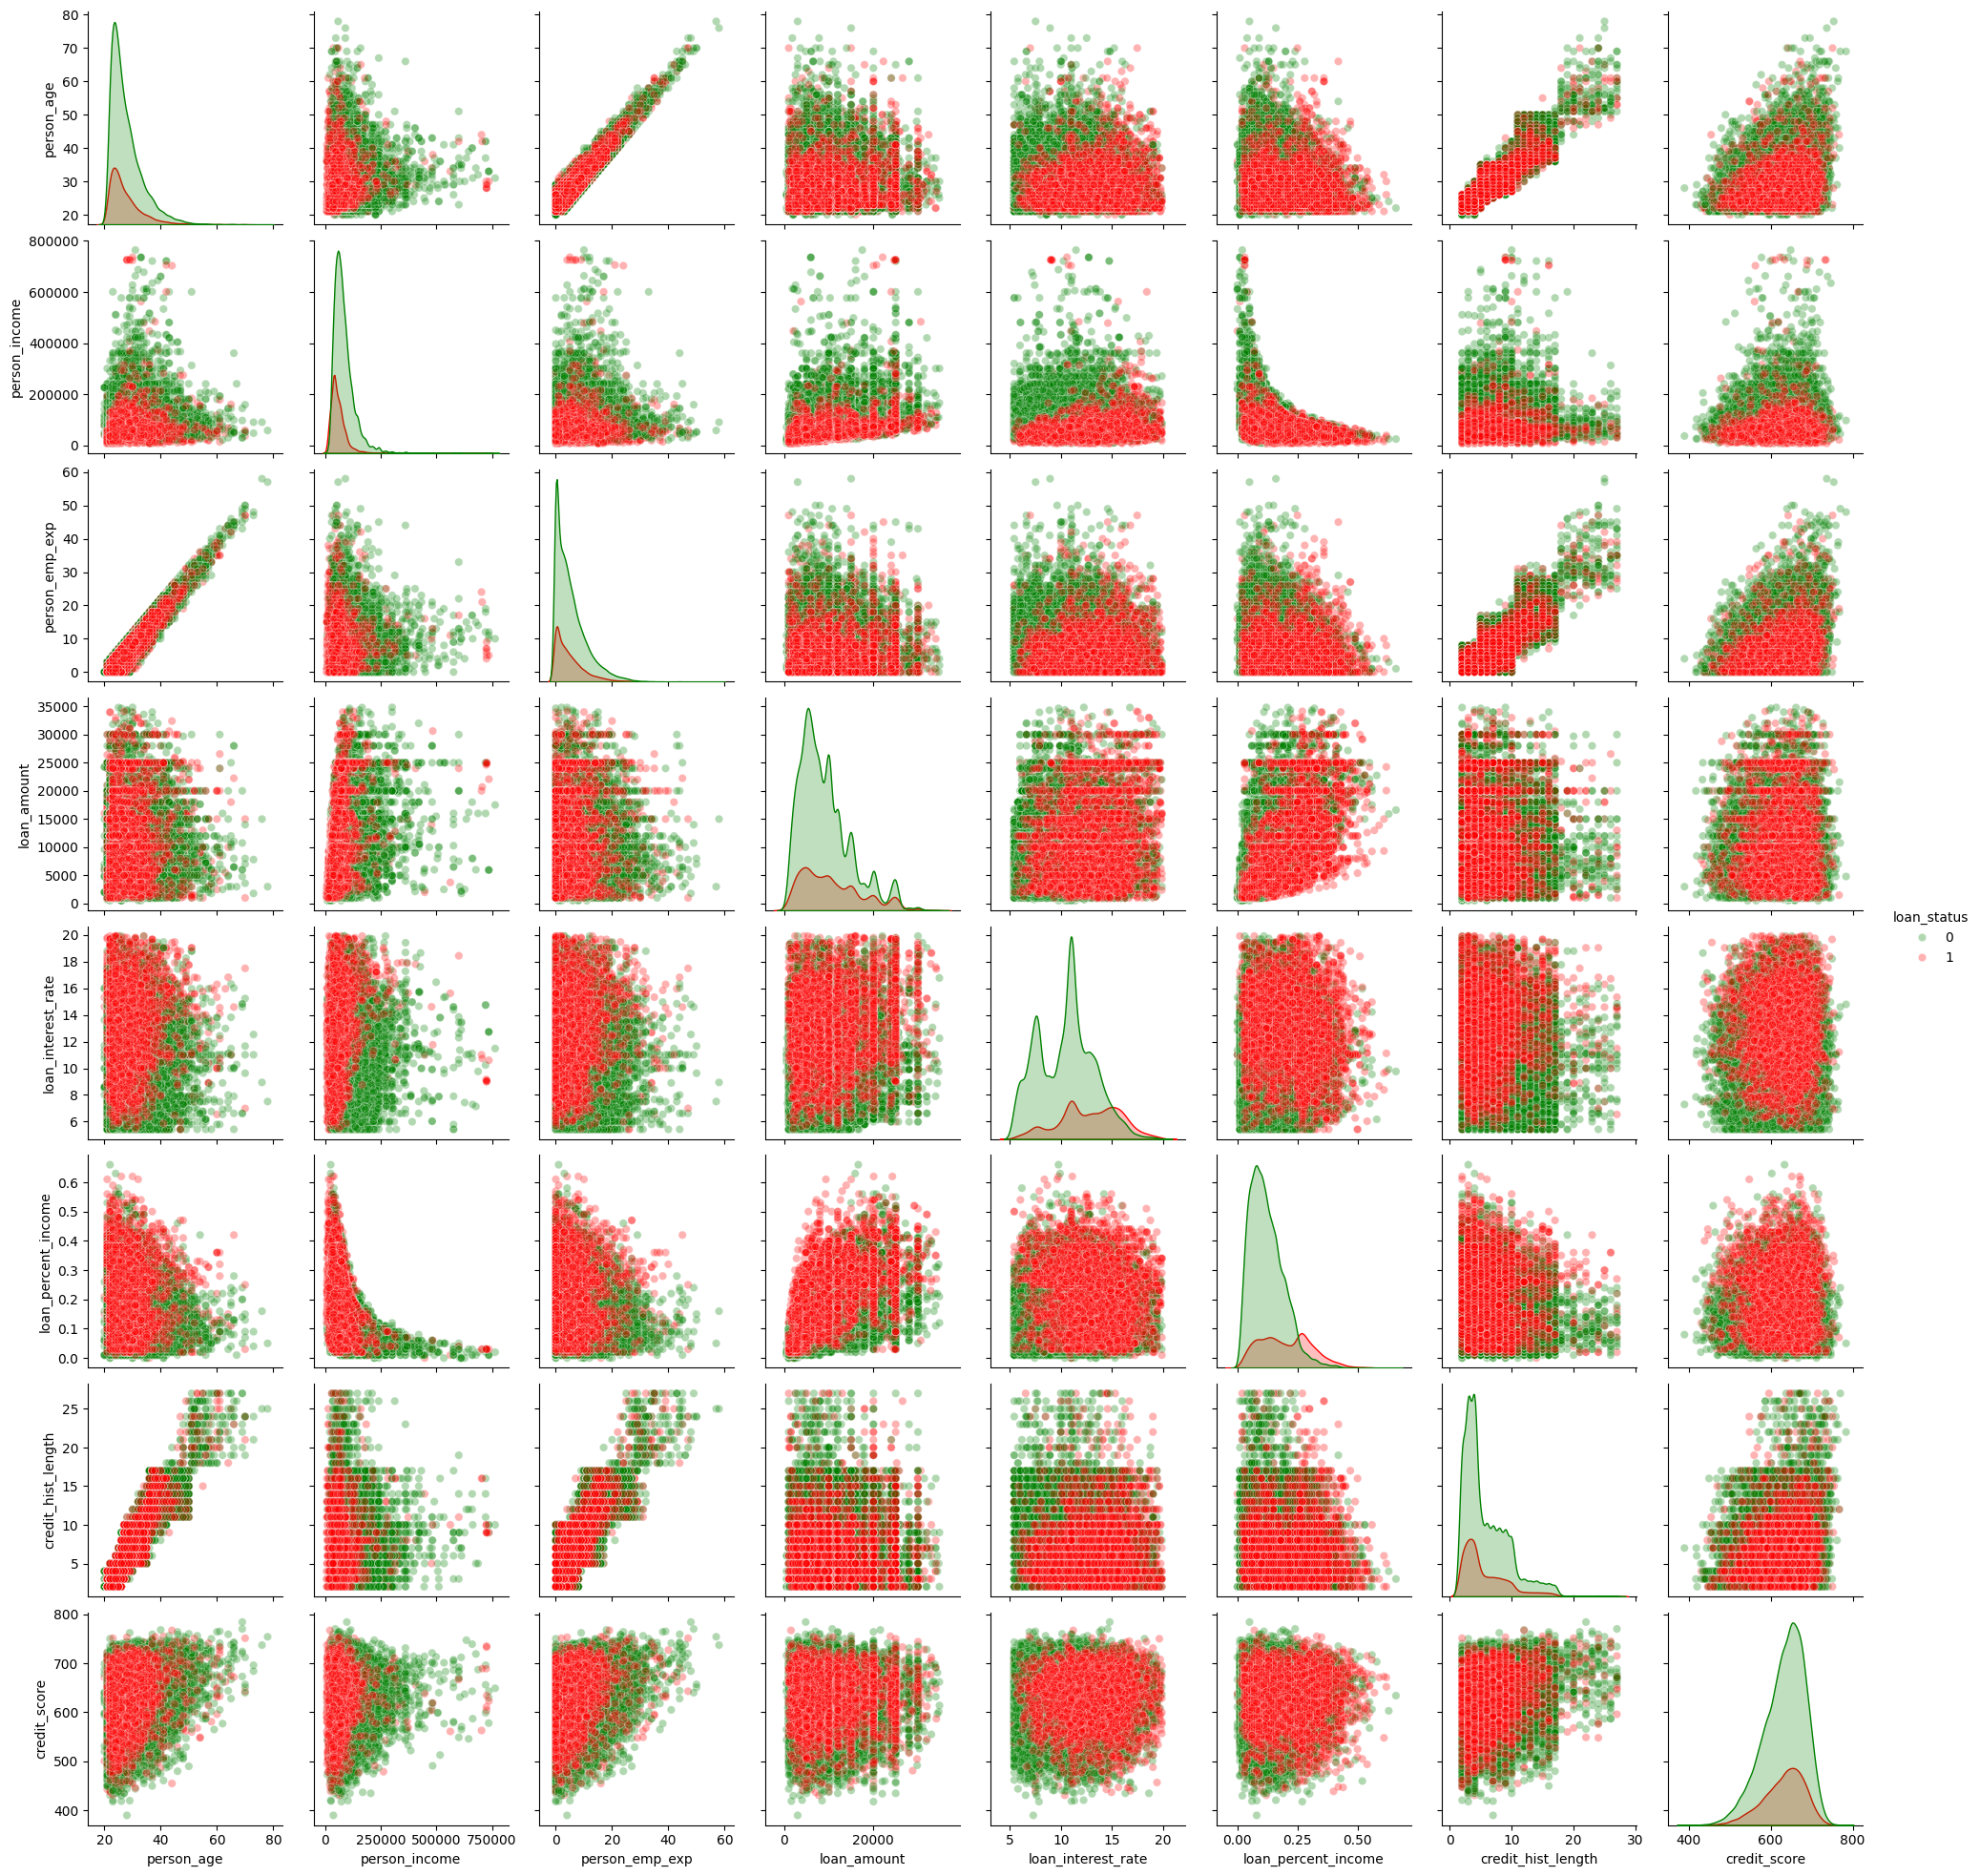

In [30]:
loan_color_map = {0: 'green', 1: 'orange'}

sns.pairplot(df[['person_age', 'person_income', 'person_emp_exp', 'loan_amount',
       'loan_interest_rate', 'loan_percent_income', 'credit_hist_length',
       'credit_score', 'loan_status']], hue='loan_status', palette=loan_color_map, diag_kind='kde', plot_kws={'alpha': 0.33})

## **Feature Engineering**

#### **Fix required features**

In [31]:
# invert prev_loan_defaults category values
df['prev_loan_defaults'] = df['prev_loan_defaults'].map({'Yes': 'No', 'No': 'Yes'})

pivot_table = pd.crosstab(df['prev_loan_defaults'], df['loan_status'])
sns.heatmap(pivot_table, annot=True, cmap='Greens')

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_interest_rate,loan_percent_income,credit_hist_length,credit_score,prev_loan_defaults,loan_status
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,No,0
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,Yes,1
5,21,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,Yes,1
9,21,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,Yes,1
11,21,female,Associate,13113.0,0,OWN,4500.0,HOMEIMPROVEMENT,8.63,0.34,2.0,651,Yes,1


<Axes: xlabel='loan_status', ylabel='prev_loan_defaults'>

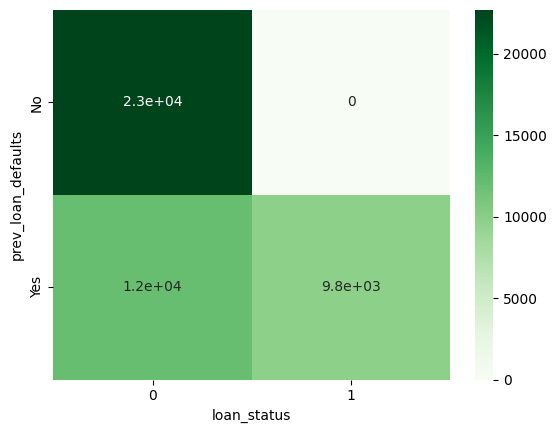

In [37]:
# convert loan_status to int type
df['loan_status'] = df['loan_status'].astype(np.int64)

## **Encode Categorical Features**

In [41]:
# get unique values for each categorical feature
df_cat = df.select_dtypes('object')

for col in df_cat.columns:
    print(f"{col} => {df[col].unique()}")

person_gender => ['female' 'male']
person_education => ['High School' 'Associate' 'Master' 'Bachelor' 'Doctorate']
person_home_ownership => ['OWN' 'MORTGAGE' 'RENT' 'OTHER']
loan_intent => ['EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT' 'DEBTCONSOLIDATION'
 'PERSONAL']
prev_loan_defaults => ['No' 'Yes']
